In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# 設定圖表風格與字型
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['Arial'] 
plt.rcParams['axes.unicode_minus'] = False


In [16]:
# 1. 讀取 YRBS 原始資料
df = pd.read_csv('YRBS_2007 (1).csv')

# 2. 篩選欄位並去除缺失值
df_project = df[['PhysicalActivity5OrMoreDays', 'SadOrHopeless']].dropna()

# 3. 定義重新編碼函數
def group_activity(row):
    if row == 1:
        return '0 days'
    elif row in [2, 3, 4]:
        return '1-3 days'
    elif row in [5, 6, 7, 8]:
        return '4+ days'
    else:
        return np.nan

# 4. 應用編碼並導出清洗後的資料檔
df_project['Activity_Group'] = df_project['PhysicalActivity5OrMoreDays'].apply(group_activity)
df_project = df_project.dropna(subset=['Activity_Group'])

# ⭐【新增這行】：明確將其轉換為類別型態，這樣就不會再跳出紅字警告了！
df_project['Activity_Group'] = df_project['Activity_Group'].astype('category')

print(f"【成功】資料處理完成。有效樣本總數：{df_project.shape[0]} 筆\n")
print("各運動組別樣本數分佈：")
print(df_project['Activity_Group'].value_counts())

# 導出符合 GitHub 要求的清洗後 CSV
df_project.to_csv('YRBS_2007_cleaned.csv', index=False)

【成功】資料處理完成。有效樣本總數：13657 筆

各運動組別樣本數分佈：
Activity_Group
4+ days     5699
1-3 days    4384
0 days      3574
Name: count, dtype: int64


In [17]:

# 執行 ANOVA 模型
model = ols('SadOrHopeless ~ C(Activity_Group)', data=df_project).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print("\n--- ANOVA 統計變異數分析表 ---")
print(anova_table)

# ⭐ 修正 FutureWarning：改用 .iloc[0] 取得 p-value
p_val = anova_table['PR(>F)'].iloc[0]

print("\n" + "-"*30 + "\n【統計學判讀結論】\n" + "-"*30)
if p_val < 0.05:
    print(f"顯著性檢定 p-value = {p_val:.4e} < 0.05。")
    print("【拒絕虛無假設 (H0)】：不同運動頻率的青少年在悲傷與絕望感上有顯著的統計差異！")
    
    # 執行事後檢定
    print("\n--- 執行事後檢定 (Tukey HSD Post-hoc Test) ---")
    tukey = pairwise_tukeyhsd(endog=df_project['SadOrHopeless'],
                              groups=df_project['Activity_Group'],
                              alpha=0.05)
    print(tukey)
else:
    print(f"顯著性檢定 p-value = {p_val:.4f} >= 0.05。")
    print("【無法拒絕虛無假設 (H0)】：運動頻率不同的青少年，其心理悲傷感無顯著差異。")


--- ANOVA 統計變異數分析表 ---
                        sum_sq       df          F        PR(>F)
C(Activity_Group)    14.692520      2.0  35.184724  5.737332e-16
Residual           2850.834756  13654.0        NaN           NaN

------------------------------
【統計學判讀結論】
------------------------------
顯著性檢定 p-value = 5.7373e-16 < 0.05。
【拒絕虛無假設 (H0)】：不同運動頻率的青少年在悲傷與絕望感上有顯著的統計差異！

--- 執行事後檢定 (Tukey HSD Post-hoc Test) ---
 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1   group2  meandiff p-adj  lower  upper  reject
------------------------------------------------------
  0 days 1-3 days   0.0289 0.0139 0.0048  0.053   True
  0 days  4+ days   0.0786    0.0 0.0558 0.1015   True
1-3 days  4+ days   0.0497    0.0 0.0282 0.0712   True
------------------------------------------------------


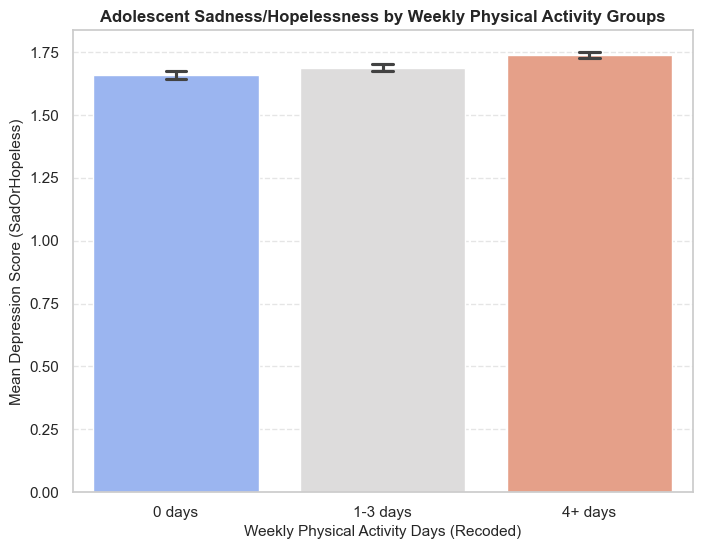

In [18]:
plt.figure(figsize=(8, 6))

# 繪製長條圖 (排除 FutureWarning)
sns.barplot(x='Activity_Group', y='SadOrHopeless', 
            data=df_project, order=['0 days', '1-3 days', '4+ days'], 
            palette='coolwarm', hue='Activity_Group', legend=False, capsize=0.1)


plt.title('Adolescent Sadness/Hopelessness by Weekly Physical Activity Groups', fontsize=12, fontweight='bold')
plt.xlabel('Weekly Physical Activity Days (Recoded)', fontsize=11)
plt.ylabel('Mean Depression Score (SadOrHopeless)', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 儲存高品質圖表
plt.savefig('anova_activity_depression.png', dpi=300, bbox_inches='tight')
plt.show()
